In [ ]:
import os
import cv2
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models

from torch.utils.data import Dataset, DataLoader

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

LR = 1e-4
BATCH_SIZE = 4
EPOCHS = 20
LAMBDA_DENSITY = 0.1

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

ZIP_SOURCE = "/content/drive/MyDrive/Glioma/BraTS_New_2D.zip"
ZIP_DEST = "/content/BraTS_New.zip"

!cp "$ZIP_SOURCE" "$ZIP_DEST"
!unzip -q /content/BraTS_New.zip -d /content/BraTS_New

Mounted at /content/drive


In [ ]:
class MultiTaskDataset(Dataset):
    def __init__(self, image_dir, mask_dir, label_csv):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.df = pd.read_csv(label_csv)

    def __len__(self):
        return len(self.df)

    def load_slice(self, patient, slice_id):
        path = os.path.join(self.image_dir, f"{patient}_{slice_id:03d}.npy")
        if os.path.exists(path):
            return np.load(path)
        else:
            return None

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        patient = row["patient_id"]
        slice_id = row["slice_id"]
        label = row["tumor_present"]

        # 🔥 Load 3 slices (prev, current, next)
        slices = []
        for sid in [slice_id - 1, slice_id, slice_id + 1]:
            s = self.load_slice(patient, sid)
            if s is None:
                s = self.load_slice(patient, slice_id)
            slices.append(s)

        image = np.concatenate(slices, axis=2)  # (H, W, 12)

        mask_path = os.path.join(self.mask_dir, f"{patient}_{slice_id:03d}_mask.png")
        mask = cv2.imread(mask_path, 0) / 255.0

        # 🔥 Resize (CRITICAL)
        image = cv2.resize(image, (128, 128))
        mask = cv2.resize(mask, (128, 128))

        # 🔥 Normalize
        image = image / (np.max(image) + 1e-8)

        # 🔥 Augmentation
        if np.random.rand() > 0.5:
            image = np.flip(image, axis=1).copy()
            mask = np.flip(mask, axis=1).copy()

        image = torch.tensor(image, dtype=torch.float32).permute(2,0,1)  # (12,H,W)
        mask = torch.tensor(mask, dtype=torch.float32).unsqueeze(0)
        label = torch.tensor(label, dtype=torch.float32)

        return image, mask, label

In [ ]:
TRAIN_IMG = "/content/BraTS_New/train/images"
TRAIN_MASK = "/content/BraTS_New/train/masks"
TRAIN_CSV = "/content/BraTS_New/train/labels.csv"

VAL_IMG = "/content/BraTS_New/val/images"
VAL_MASK = "/content/BraTS_New/val/masks"
VAL_CSV = "/content/BraTS_New/val/labels.csv"

In [ ]:
train_dataset = MultiTaskDataset(TRAIN_IMG, TRAIN_MASK, TRAIN_CSV)
val_dataset = MultiTaskDataset(VAL_IMG, VAL_MASK, VAL_CSV)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

old_w = vgg.features[0].weight
vgg.features[0] = nn.Conv2d(12, 64, 3, padding=1)

with torch.no_grad():
    vgg.features[0].weight[:, :3] = old_w
    vgg.features[0].weight[:, 3:] = old_w[:, :1].repeat(1,9,1,1)

features = vgg.features.to(device)

Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:06<00:00, 84.5MB/s]


In [ ]:
yolo_conv = nn.Conv2d(512, 256, 3, padding=1).to(device)
yolo_bn = nn.BatchNorm2d(256).to(device)
yolo_fc = nn.Linear(256, 1).to(device)

def yolo_forward(x):
    x = F.silu(yolo_bn(yolo_conv(x)))
    x = F.adaptive_avg_pool2d(x, 1).view(x.size(0), -1)
    return torch.sigmoid(yolo_fc(x)).squeeze()

In [ ]:
hdsa_d1 = nn.Conv2d(512, 512, 3, padding=1, dilation=1).to(device)
hdsa_d2 = nn.Conv2d(512, 512, 3, padding=2, dilation=2).to(device)
hdsa_d3 = nn.Conv2d(512, 512, 3, padding=3, dilation=3).to(device)

hdsa_attn = nn.Conv2d(512, 1, 1).to(device)

def hdsa_forward(x):
    d1 = hdsa_d1(x)
    d2 = hdsa_d2(x)
    d3 = hdsa_d3(x)

    fused = d1 + d2 + d3
    attn = torch.sigmoid(hdsa_attn(fused))

    return fused * attn

In [ ]:
up1 = nn.ConvTranspose2d(512, 256, 2, 2).to(device)
conv1 = nn.Conv2d(256, 256, 3, padding=1).to(device)

up2 = nn.ConvTranspose2d(256, 128, 2, 2).to(device)
conv2 = nn.Conv2d(128, 128, 3, padding=1).to(device)

up3 = nn.ConvTranspose2d(128, 64, 2, 2).to(device)
conv3 = nn.Conv2d(64, 64, 3, padding=1).to(device)

seg_out = nn.Conv2d(64, 1, 1).to(device)

In [ ]:
# Skip connection channel alignment
skip4 = nn.Conv2d(512, 256, 1).to(device)
skip3 = nn.Conv2d(256, 128, 1).to(device)
skip2 = nn.Conv2d(128, 64, 1).to(device)

In [ ]:
def forward_pass(x):

    f1 = features[:5](x)
    f2 = features[5:10](f1)
    f3 = features[10:17](f2)
    f4 = features[17:24](f3)
    f5 = features[24:](f4)

    cls = yolo_forward(f5)

    h = hdsa_forward(f5)

    s = F.relu(conv1(up1(h)))
    s = s + skip4(f4)

    s = F.relu(conv2(up2(s)))
    s = s + skip3(f3)

    s = F.relu(conv3(up3(s)))
    s = s + skip2(f2)

    seg = torch.sigmoid(seg_out(s))
    seg = F.interpolate(seg, size=x.shape[2:], mode='bilinear', align_corners=False)

    return cls, seg

In [ ]:
def dice_loss(pred, target):
    # 🔥 FIX: resize prediction to match target
    if pred.shape != target.shape:
        pred = F.interpolate(pred, size=target.shape[2:], mode='bilinear', align_corners=False)

    pred = pred.view(-1)
    target = target.view(-1)

    inter = (pred * target).sum()
    return 1 - (2 * inter + 1) / (pred.sum() + target.sum() + 1)
def compute_metrics(cls_p, cls_t, seg_p, seg_t):

    # 🔥 Ensure same size
    if seg_p.shape != seg_t.shape:
        seg_p = F.interpolate(seg_p, size=seg_t.shape[2:], mode='bilinear', align_corners=False)

    acc = ((cls_p > 0.5) == cls_t).float().mean()

    seg_p = (seg_p > 0.5).float()
    inter = (seg_p * seg_t).sum()
    union = seg_p.sum() + seg_t.sum() - inter

    dice = (2 * inter) / (seg_p.sum() + seg_t.sum() + 1e-6)
    iou = inter / (union + 1e-6)

    return acc.item(), dice.item(), iou.item()

In [ ]:
def focal_loss(pred, target, alpha=0.8, gamma=2):
    bce = F.binary_cross_entropy(pred, target, reduction='none')
    pt = torch.exp(-bce)
    return (alpha * (1 - pt) ** gamma * bce).mean()


def RAL_loss(cls_p, cls_t, seg_p, seg_t, x):

    bce = nn.BCELoss()

    # Classification
    L_cls = bce(cls_p, cls_t)

    # 🔥 Strong segmentation loss
    weighted_bce = nn.BCELoss(weight=(seg_t * 6 + 1))
    L_seg = 0.4 * dice_loss(seg_p, seg_t) + \
            0.3 * weighted_bce(seg_p, seg_t) + \
            0.3 * focal_loss(seg_p, seg_t)

    density = torch.mean(seg_p)
    L_density = torch.abs(density - 0.5)

    return 0.2 * L_cls + 0.8 * L_seg + 0.1 * L_density

In [ ]:
params = list(features.parameters()) + \
         list(yolo_conv.parameters()) + list(yolo_bn.parameters()) + list(yolo_fc.parameters()) + \
         list(hdsa_d1.parameters()) + list(hdsa_d2.parameters()) + list(hdsa_d3.parameters()) + \
         list(hdsa_attn.parameters()) + \
         list(up1.parameters()) + list(up2.parameters()) + list(up3.parameters()) + \
         list(seg_out.parameters())
params += list(skip4.parameters()) + list(skip3.parameters()) + list(skip2.parameters())

optimizer = torch.optim.Adam(params, lr=LR)

In [ ]:
def train_epoch(loader):
    features.train()
    total = 0

    for x, m, y in loader:
        x, m, y = x.to(device), m.to(device), y.to(device)

        optimizer.zero_grad()

        cls, seg = forward_pass(x)

        loss = RAL_loss(cls, y, seg, m, x)
        loss.backward()

        optimizer.step()

        total += loss.item()

    return total / len(loader)

In [ ]:
def validate(loader):
    features.eval()

    losses = []
    accs, dices, ious = [], [], []

    with torch.no_grad():
        for x, m, y in loader:
            x, m, y = x.to(device), m.to(device), y.to(device)

            cls, seg = forward_pass(x)

            # ✅ FIX HERE
            loss = RAL_loss(cls, y, seg, m, x)
            losses.append(loss.item())

            acc, dice, iou = compute_metrics(cls, y, seg, m)

            accs.append(acc)
            dices.append(dice)
            ious.append(iou)

    return (
        np.mean(losses),
        np.mean(accs),
        np.mean(dices),
        np.mean(ious)
    )

In [ ]:
activations = None
gradients = None

def fwd_hook(m, i, o):
    global activations
    activations = o

def bwd_hook(m, gi, go):
    global gradients
    gradients = go[0]

features[-1].register_forward_hook(fwd_hook)
features[-1].register_full_backward_hook(bwd_hook)

def gradcam_plus_plus(x):
    cls, _ = forward_pass(x)
    cls.mean().backward()

    w = gradients.mean(dim=(2,3), keepdim=True)
    cam = (w * activations).sum(dim=1)

    cam = F.relu(cam)
    cam = F.interpolate(cam.unsqueeze(1), size=x.shape[2:], mode='bilinear')

    return cam.squeeze().detach().cpu().numpy()

In [ ]:
# Store training history
train_losses = []
val_losses = []
val_accuracies = []
val_dice_scores = []
val_ious = []

best_loss = float("inf")

In [ ]:
for epoch in range(EPOCHS):
    train_loss = train_epoch(train_loader)
    val_loss, acc, dice, iou = validate(val_loader)

    # Save metrics
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(acc)
    val_dice_scores.append(dice)
    val_ious.append(iou)

    print(f"Epoch {epoch+1}:")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Acc: {acc:.4f}, Dice: {dice:.4f}, IoU: {iou:.4f}")

    # Save best model
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(features.state_dict(), "best_model.pth")
        print("✅ Best model saved")

Epoch 1:
Train Loss: 0.2425
Val Loss: 0.2977, Acc: 0.7837, Dice: 0.5537, IoU: 0.4507
✅ Best model saved
Epoch 2:
Train Loss: 0.2371
Val Loss: 0.2360, Acc: 0.9010, Dice: 0.5828, IoU: 0.4833
✅ Best model saved
Epoch 3:
Train Loss: 0.2200
Val Loss: 0.2396, Acc: 0.9015, Dice: 0.5824, IoU: 0.4798
Epoch 4:
Train Loss: 0.2121
Val Loss: 0.2229, Acc: 0.9094, Dice: 0.5778, IoU: 0.4765
✅ Best model saved
Epoch 5:
Train Loss: 0.2074
Val Loss: 0.2552, Acc: 0.9054, Dice: 0.5635, IoU: 0.4582
Epoch 6:
Train Loss: 0.2047
Val Loss: 0.2003, Acc: 0.9188, Dice: 0.5899, IoU: 0.4912
✅ Best model saved
Epoch 7:
Train Loss: 0.1917
Val Loss: 0.2148, Acc: 0.9213, Dice: 0.5848, IoU: 0.4814
Epoch 8:
Train Loss: 0.1936
Val Loss: 0.2105, Acc: 0.9238, Dice: 0.5887, IoU: 0.4877
Epoch 9:
Train Loss: 0.1943
Val Loss: 0.2082, Acc: 0.9114, Dice: 0.5890, IoU: 0.4875
Epoch 10:
Train Loss: 0.1856
Val Loss: 0.1875, Acc: 0.9401, Dice: 0.5908, IoU: 0.4903
✅ Best model saved
Epoch 11:
Train Loss: 0.1852
Val Loss: 0.1976, Acc: 0.

In [ ]:
# Save full training data
torch.save({
    "model_state_dict": features.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_accuracies": val_accuracies,
    "val_dice_scores": val_dice_scores,
    "val_ious": val_ious
}, "training_complete.pth")

In [ ]:
save_path = "/content/drive/MyDrive/Glioma/"
torch.save({
    "model_state_dict": features.state_dict(),
    "optimizer_state_dict": optimizer.state_dict(),
    "train_losses": train_losses,
    "val_losses": val_losses,
    "val_accuracies": val_accuracies,
    "val_dice_scores": val_dice_scores,
    "val_ious": val_ious
}, save_path + "training_complete.pth")

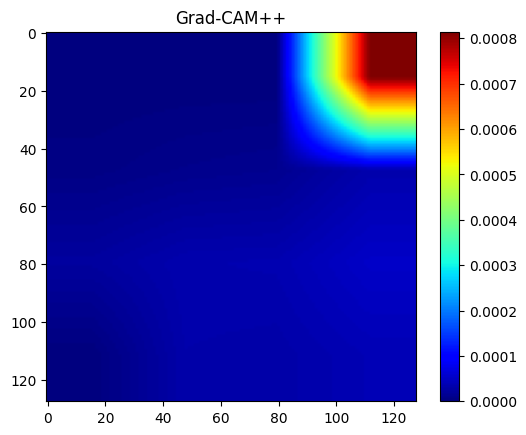

In [ ]:
sample = next(iter(val_loader))[0][0].unsqueeze(0).to(device)

heatmap = gradcam_plus_plus(sample)

import matplotlib.pyplot as plt
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM++")
plt.colorbar()
plt.show()

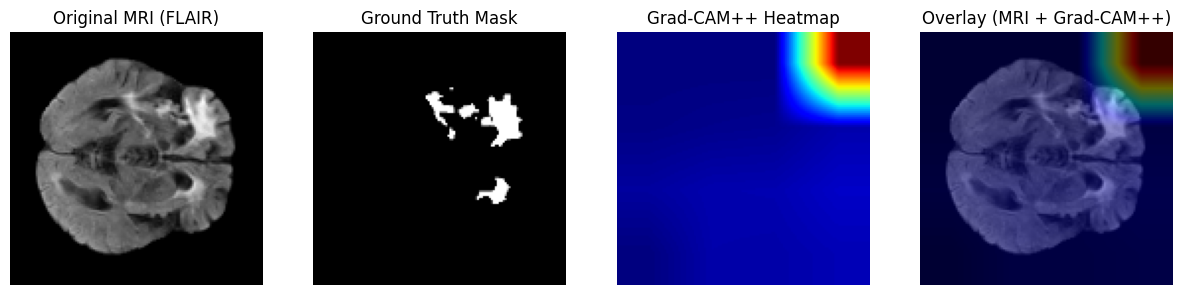

In [ ]:
import matplotlib.pyplot as plt
import cv2

# Get sample
images, masks, labels = next(iter(val_loader))

img = images[0].cpu().numpy()      # (4, H, W)
mask = masks[0].cpu().numpy()      # (1, H, W)

# Use one modality for visualization (FLAIR is best usually)
base_img = img[3]   # flair channel

# Normalize image for display
base_img = (base_img - base_img.min()) / (base_img.max() - base_img.min() + 1e-8)

# Prepare input
input_tensor = images[0].unsqueeze(0).to(device)

# Generate Grad-CAM
heatmap = gradcam_plus_plus(input_tensor)

# Normalize heatmap
heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

# Resize heatmap to image size
heatmap_resized = cv2.resize(heatmap, (base_img.shape[1], base_img.shape[0]))

# Convert to color map
heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB) / 255.0

# Convert base image to RGB
base_rgb = np.stack([base_img]*3, axis=-1)

# Overlay
overlay = 0.6 * base_rgb + 0.4 * heatmap_color

# Plot
plt.figure(figsize=(15,5))

plt.subplot(1,4,1)
plt.imshow(base_img, cmap='gray')
plt.title("Original MRI (FLAIR)")
plt.axis('off')

plt.subplot(1,4,2)
plt.imshow(mask.squeeze(), cmap='gray')
plt.title("Ground Truth Mask")
plt.axis('off')

plt.subplot(1,4,3)
plt.imshow(heatmap_resized, cmap='jet')
plt.title("Grad-CAM++ Heatmap")
plt.axis('off')

plt.subplot(1,4,4)
plt.imshow(overlay)
plt.title("Overlay (MRI + Grad-CAM++)")
plt.axis('off')

plt.show()

In [ ]:
all_preds = []
all_labels = []

features.eval()

with torch.no_grad():
    for x, m, y in val_loader:
        x = x.to(device)

        cls, _ = forward_pass(x)

        all_preds.extend(cls.cpu().numpy())
        all_labels.extend(y.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

In [ ]:
threshold = 0.5
pred_binary = (all_preds > threshold).astype(int)

In [ ]:
from sklearn.metrics import confusion_matrix

tn, fp, fn, tp = confusion_matrix(all_labels, pred_binary).ravel()

accuracy = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp + 1e-8)
recall = tp / (tp + fn + 1e-8)  # Sensitivity
specificity = tn / (tn + fp + 1e-8)
f1 = 2 * precision * recall / (precision + recall + 1e-8)

print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall (Sens): {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")

Accuracy     : 0.9436
Precision    : 0.9657
Recall (Sens): 0.9198
Specificity  : 0.9673
F1 Score     : 0.9422


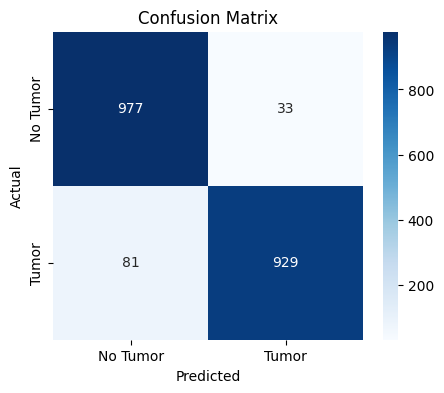

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(all_labels, pred_binary)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=["No Tumor", "Tumor"],
            yticklabels=["No Tumor", "Tumor"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

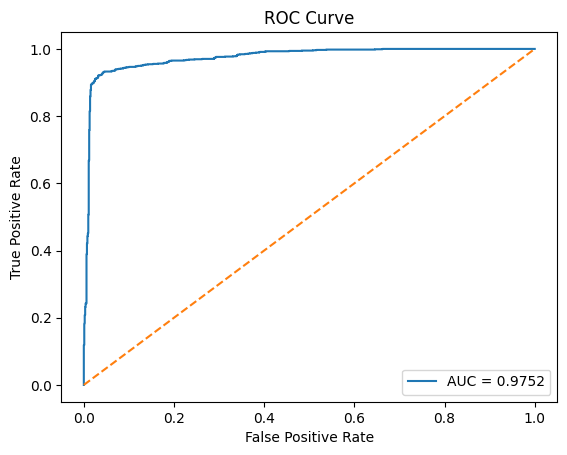

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(all_labels, all_preds)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

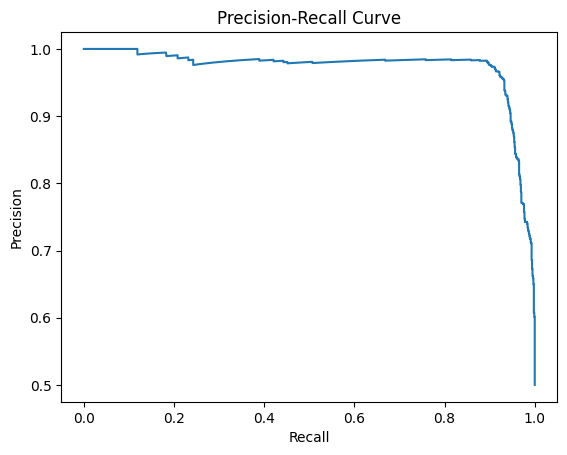

In [ ]:
from sklearn.metrics import precision_recall_curve

precision_vals, recall_vals, _ = precision_recall_curve(all_labels, all_preds)

plt.figure()
plt.plot(recall_vals, precision_vals)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

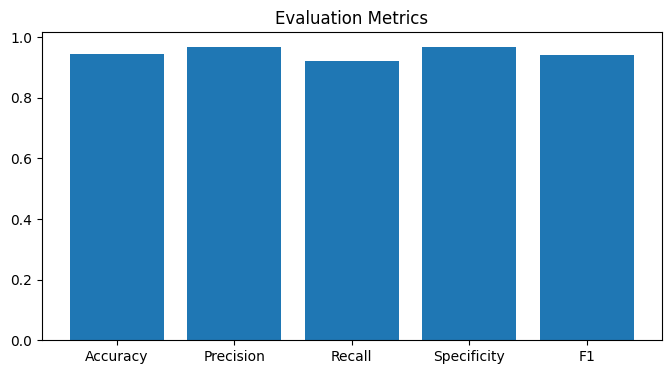

In [ ]:
metrics = [accuracy, precision, recall, specificity, f1]
names = ["Accuracy", "Precision", "Recall", "Specificity", "F1"]

plt.figure(figsize=(8,4))
plt.bar(names, metrics)
plt.title("Evaluation Metrics")
plt.show()

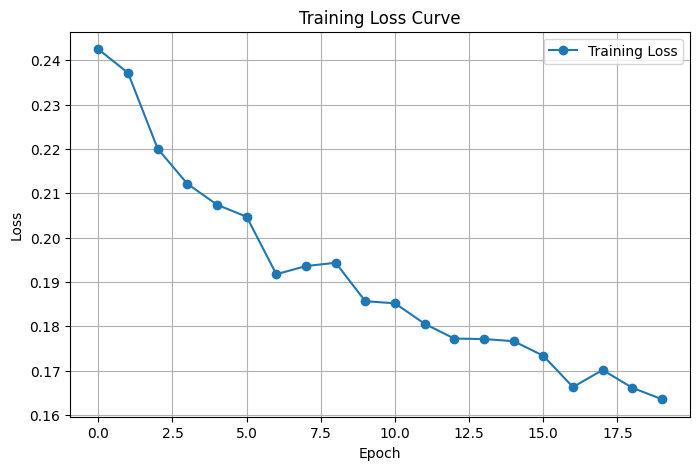

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss", marker='o')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")
plt.legend()
plt.grid()

plt.show()

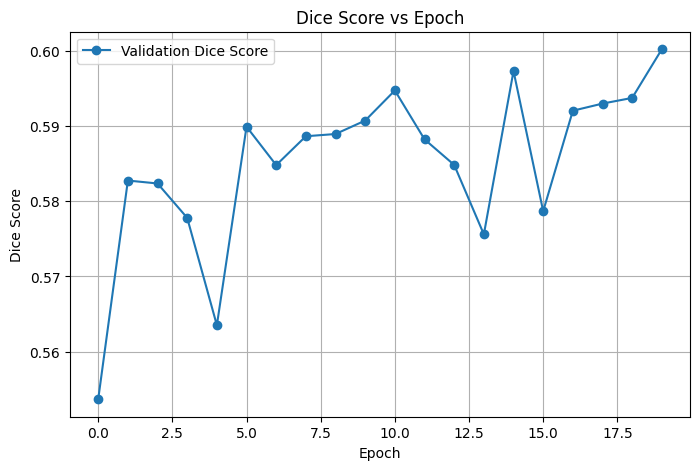

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(val_dice_scores, label="Validation Dice Score", marker='o')

plt.xlabel("Epoch")
plt.ylabel("Dice Score")
plt.title("Dice Score vs Epoch")
plt.legend()
plt.grid()

plt.show()

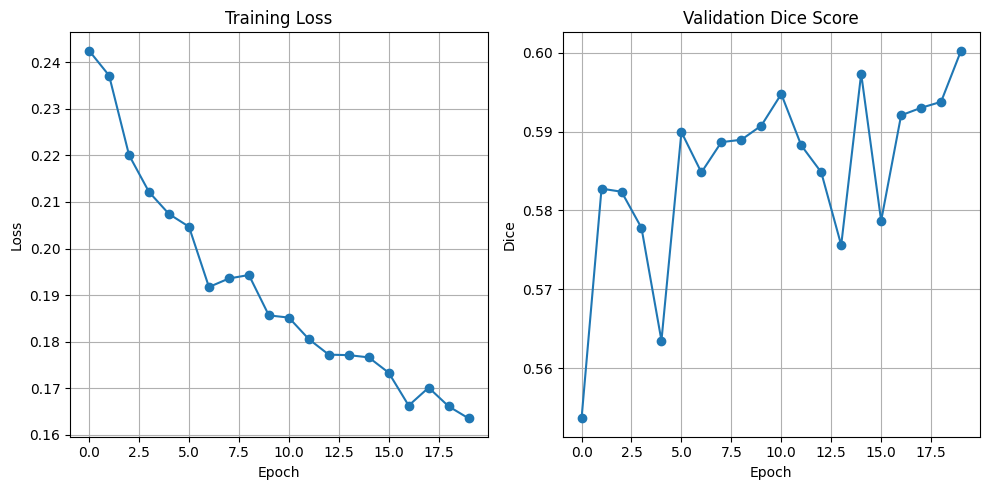

In [ ]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.plot(train_losses, marker='o')
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid()

plt.subplot(1,2,2)
plt.plot(val_dice_scores, marker='o')
plt.title("Validation Dice Score")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.grid()

plt.tight_layout()
plt.show()